## Project Introduction
This notebook explores a video game dataset containing detailed game information and user ratings. It focuses on cleaning, preprocessing, and analyzing the data to build a machine learning model that predicts whether a game will be highly rated or not. The project aims to identify key factors that influence game ratings and transform raw data into meaningful insights for predictive modeling.

### Objectives:
- Clean and preprocess the dataset by handling missing values, duplicates, and inconsistent entries
- Define a target variable to classify games as "highly rated" or "not highly rated"
- Identify patterns and relationships between game features and ratings
- Build and evaluate machine learning models for binary classification
- Interpret feature importance to understand what drives high game ratings

### Tools and Libraries:
- Python (Jupyter Notebook)
- Pandas, NumPy for data manipulation
- Matplotlib, Seaborn for visualization
- Scikit-learn for machine learning modeling and evaluation

In [104]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

In [105]:
#import data
df = pd.read_csv('../data/raw_data/game_info.csv')
df

,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17T11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06T23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22T13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28T22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17T13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474412,99994,holy-or-dead,Holy or Dead,NaN,2017-05-17,False,2019-01-09T12:41:06,NaN,0.0,0,...,Ralidon,NaN,NaN,NaN,0,0,0,0,0,0
474413,99995,airstrike-hd-demo,Airstrike HD Demo,NaN,2016-03-04,False,2019-01-09T12:41:06,NaN,0.0,0,...,Fifth Dimension Company,Action,NaN,NaN,0,0,0,0,0,0
474414,99997,uranias-mirror,Urania's Mirror,NaN,2016-04-25,False,2019-01-09T12:41:06,NaN,0.0,0,...,sneakthief,Adventure,NaN,NaN,0,0,0,0,0,0
474415,99998,simucities,Simucities,NaN,2017-05-26,False,2019-01-09T12:41:06,NaN,0.0,0,...,keypixels,NaN,NaN,NaN,0,0,0,0,0,0


## EDA


In [106]:
#exploring null values
df.isnull().mean().sort_values(ascending=False) * 100

metacritic              99.002354
esrb_rating             88.224705
website                 86.290331
publishers              70.275939
genres                  21.749853
released                 5.100787
developers               1.763428
platforms                0.840189
name                     0.000632
slug                     0.000422
id                       0.000000
added_status_dropped     0.000000
added_status_toplay      0.000000
added_status_beaten      0.000000
added_status_owned       0.000000
added_status_yet         0.000000
suggestions_count        0.000000
reviews_count            0.000000
game_series_count        0.000000
ratings_count            0.000000
achievements_count       0.000000
playtime                 0.000000
rating_top               0.000000
rating                   0.000000
updated                  0.000000
tba                      0.000000
added_status_playing     0.000000
dtype: float64

In [107]:
#exploring the rating of the games
rated_games = df[df['rating'] > 0]

print("Rows:", len(rated_games))

rated_games[['rating']].describe()

Rows: 11994


,rating
count,11994.000000
mean,3.390744
std,0.737789
min,1.000000
25%,2.920000
50%,3.520000
75%,3.990000
max,5.000000


In [108]:
# Data overview
print("Data overview:")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst few rows:\n{df.head()}")



Data overview:
Shape: (474417, 27)

Data types:
id                        int64
slug                     object
name                     object
metacritic              float64
released                 object
tba                        bool
updated                  object
website                  object
rating                  float64
rating_top                int64
playtime                  int64
achievements_count        int64
ratings_count             int64
suggestions_count         int64
game_series_count         int64
reviews_count             int64
platforms                object
developers               object
genres                   object
publishers               object
esrb_rating              object
added_status_yet          int64
added_status_owned        int64
added_status_beaten       int64
added_status_toplay       int64
added_status_dropped      int64
added_status_playing      int64
dtype: object

First few rows:
      id            slug                   name  metacrit

In [109]:
# Missing values overview
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

Missing values:
             Missing_Count  Percentage
metacritic          469684   99.002354
esrb_rating         418553   88.224705
website             409376   86.290331
publishers          333401   70.275939
genres              103185   21.749853
released             24199    5.100787
developers            8366    1.763428
platforms             3986    0.840189
name                     3    0.000632
slug                     2    0.000422


In [110]:
# Numerical features
print("Numerical features:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

Numerical features:


,id,metacritic,rating,rating_top,playtime,achievements_count,ratings_count,suggestions_count,game_series_count,reviews_count,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
count,474417.000000,4733.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000
mean,266884.000325,73.159307,0.085723,0.098829,0.221662,4.448837,2.142463,92.196848,0.044282,2.162783,0.685030,11.251418,1.361486,0.430767,0.678100,0.149027
std,154567.811630,11.502213,0.545049,0.613023,5.399684,117.671466,36.553606,116.493695,0.771472,36.868160,9.012424,128.531595,28.519725,8.970948,10.484977,3.911149
min,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,133664.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,267945.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,406010.000000,81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,122.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,525551.000000,99.000000,5.000000,5.000000,1600.000000,12322.000000,4289.000000,1839.000000,28.000000,4334.000000,635.000000,8298.000000,3533.000000,2325.000000,1092.000000,644.000000


In [111]:
# Rating analysis
print("Rating analysis:")
print(f"Rating range: {df['rating'].min()} to {df['rating'].max()}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index().head(15))


Rating analysis:
Rating range: 0.0 to 5.0

Rating distribution:
rating
0.00    462423
1.00         6
1.11         1
1.13         1
1.17         1
1.18         1
1.21         1
1.22         4
1.24         1
1.25         4
1.29        15
1.30         1
1.31         1
1.33        23
1.35         2
Name: count, dtype: int64


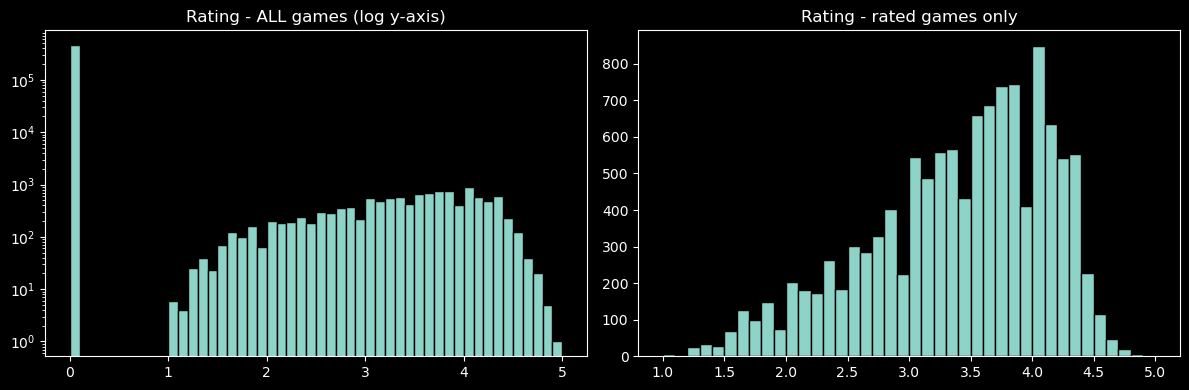

In [112]:
#visualize rating dsitribution
rated_all = df[df['rating'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['rating'], bins=50, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Rating - ALL games (log y-axis)')
axes[1].hist(rated_all['rating'], bins=40, edgecolor='black')
axes[1].set_title('Rating - rated games only')
plt.tight_layout()
plt.show()

In [113]:
# Categorical features
print("Categorical features:")
print(f"Unique ESRB ratings: {df['esrb_rating'].unique()}")
print(f"\nESRB distribution:\n{df['esrb_rating'].value_counts()}")



Categorical features:
Unique ESRB ratings: ['Everyone 10+' 'Everyone' 'Teen' nan 'Mature' 'Adults Only'
 'Rating Pending']

ESRB distribution:
esrb_rating
Everyone 10+      36682
Teen              10031
Mature             4859
Everyone           3837
Adults Only         405
Rating Pending       50
Name: count, dtype: int64


In [114]:
# Key metrics distribution
key_metrics = ['metacritic', 'playtime', 'ratings_count', 'achievements_count', 'reviews_count']
print(df[key_metrics].describe())

        metacritic       playtime  ratings_count  achievements_count  \
count  4733.000000  474417.000000  474417.000000       474417.000000   
mean     73.159307       0.221662       2.142463            4.448837   
std      11.502213       5.399684      36.553606          117.671466   
min      15.000000       0.000000       0.000000            0.000000   
25%      67.000000       0.000000       0.000000            0.000000   
50%      75.000000       0.000000       0.000000            0.000000   
75%      81.000000       0.000000       0.000000            0.000000   
max      99.000000    1600.000000    4289.000000        12322.000000   

       reviews_count  
count  474417.000000  
mean        2.162783  
std        36.868160  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max      4334.000000  


In [115]:
# Checking dupplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [116]:
# platform & fenre analysis
print(f"Sample platforms: {df['platforms'].head(3).values}")
print(f"Sample genres: {df['genres'].head(3).values}")

Sample platforms: ['PC||macOS||Xbox One||PlayStation 4||Nintendo Switch'
 'macOS||PC||Xbox One' 'iOS']
Sample genres: ['Adventure||Puzzle' 'Simulation||Indie' 'Adventure||Arcade']


 min_ratings  games_left  rating_std
           1       11994       0.738
           5       11987       0.738
          10        8969       0.709
          20        5880       0.650
          50        3195       0.586


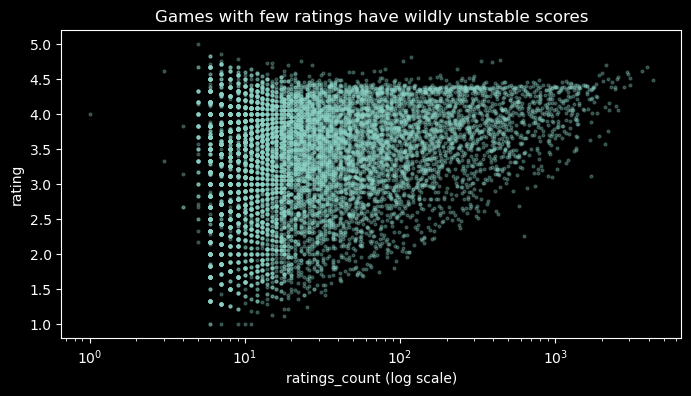

In [117]:
# how many ratings does a game need before its score is trustworthy?
rated_all = df[df['rating'] > 0].copy()

rows = []
for t in [1, 5, 10, 20, 50]:
    sub = rated_all[rated_all['ratings_count'] >= t]
    rows.append({'min_ratings': t, 'games_left': len(sub), 'rating_std': round(sub['rating'].std(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.scatter(rated_all['ratings_count'], rated_all['rating'], s=4, alpha=0.3)
plt.xscale('log')
plt.xlabel('ratings_count (log scale)')
plt.ylabel('rating')
plt.title('Games with few ratings have wildly unstable scores')
plt.show()

Games kept: 8969
Missing release year: 89
Release year > 2020 (unreleased/junk): 2
Release year < 2000: 1001


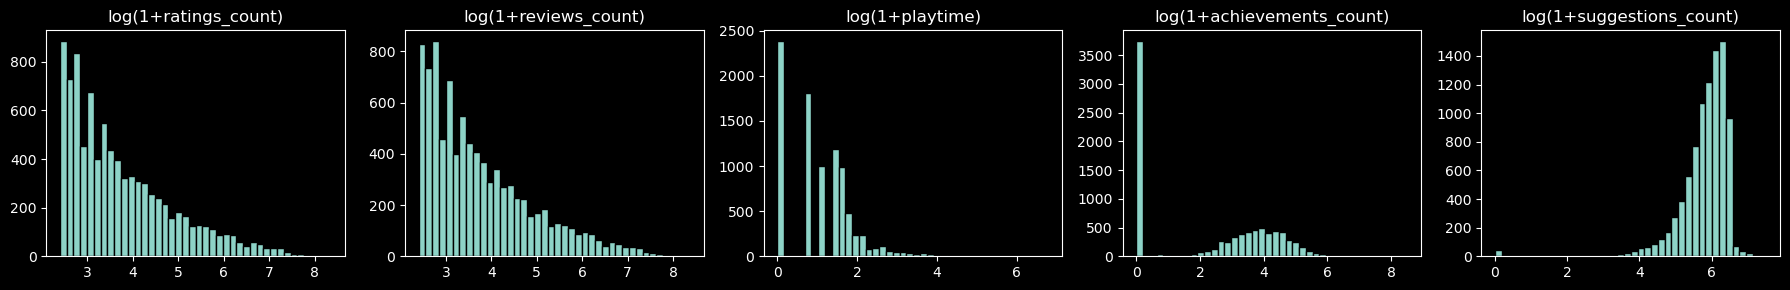

In [118]:
# rating cutoff -> low cutoff means more data but noisier labels, high cutoff means clean lables but few rows
# 10 is a suitable cutoff, evident from above

MIN_RATINGS = 10   

rated = rated_all[rated_all['ratings_count'] >= MIN_RATINGS].copy()
rated['released'] = pd.to_datetime(rated['released'], errors='coerce')
rated['release_year'] = rated['released'].dt.year

print("Games kept:", len(rated))
print("Missing release year:", rated['release_year'].isnull().sum())
print("Release year > 2020 (unreleased/junk):", (rated['release_year'] > 2020).sum())
print("Release year < 2000:", (rated['release_year'] < 2000).sum())

skew_cols = ['ratings_count', 'reviews_count', 'playtime', 'achievements_count', 'suggestions_count']
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, c in zip(axes, skew_cols):
    ax.hist(np.log1p(rated[c]), bins=40, edgecolor='black')
    ax.set_title(f'log(1+{c})')
plt.tight_layout()
plt.show()

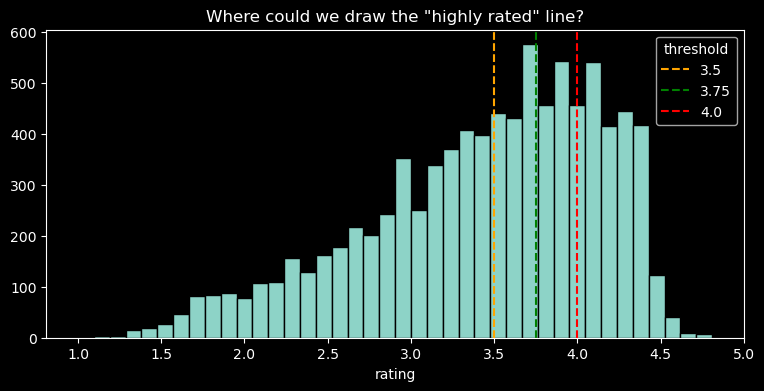

 threshold  pct_high  n_high
      3.50      54.0    4842
      3.75      39.7    3562
      4.00      25.9    2321
      4.25      11.3    1011
high_rated
0    6648
1    2321
Name: count, dtype: int64


In [119]:
# defining targets
plt.figure(figsize=(9, 4))
plt.hist(rated['rating'], bins=40, edgecolor='black')
for t, c in [(3.5, 'orange'), (3.75, 'green'), (4.0, 'red')]:
    plt.axvline(t, color=c, linestyle='--', label=f'{t}')
plt.legend(title='threshold')
plt.xlabel('rating')
plt.title('Where could we draw the "highly rated" line?')
plt.show()

thr = [3.5, 3.75, 4.0, 4.25]
print(pd.DataFrame({
    'threshold': thr,
    'pct_high': [round((rated['rating'] >= t).mean()*100, 1) for t in thr],
    'n_high':   [int((rated['rating'] >= t).sum()) for t in thr]
}).to_string(index=False))

HIGH_THRESHOLD = 4.0   
# threshold chosen as 4.0 bcz, 26% postive, 74% never high, best trade-off between meaning and having enough positives (2,321)
rated['high_rated'] = (rated['rating'] >= HIGH_THRESHOLD).astype(int)
print(rated['high_rated'].value_counts())

rating_top              0.828
metacritic              0.634
added_status_beaten     0.561
added_status_toplay     0.485
added_status_playing    0.377
game_series_count       0.288
reviews_count           0.250
ratings_count           0.247
added_status_dropped    0.138
suggestions_count       0.042
added_status_yet       -0.078
playtime               -0.079
achievements_count     -0.199
added_status_owned     -0.295
Name: rating, dtype: float64


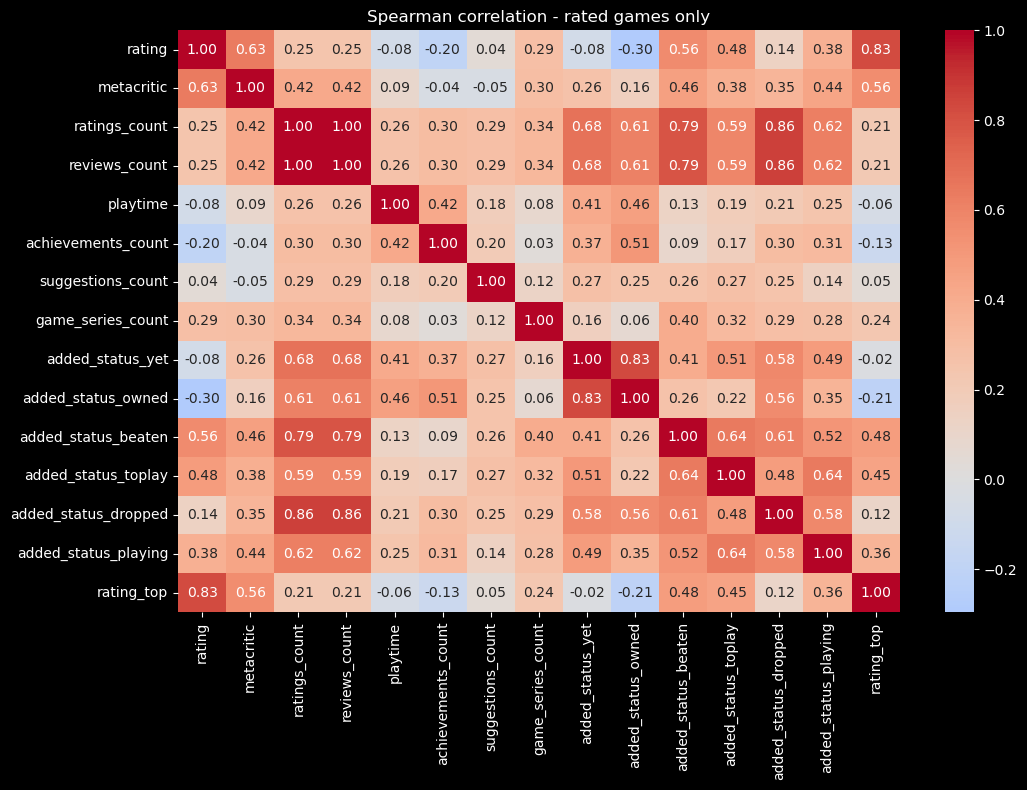

In [120]:
num_cols = ['rating', 'metacritic', 'ratings_count', 'reviews_count', 'playtime', 'achievements_count',
            'suggestions_count', 'game_series_count', 'added_status_yet', 'added_status_owned',
            'added_status_beaten', 'added_status_toplay', 'added_status_dropped',
            'added_status_playing', 'rating_top']

corr = rated[num_cols].corr(method='spearman') #spearman used bcz columns are heavilu skewed
print(corr['rating'].drop('rating').sort_values(ascending=False).round(3))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman correlation - rated games only')
plt.tight_layout()
plt.show()

#rating_top (0.83), added_status_beaten (0.56), added_status_toplay (0.49) and added_status_playing (0.38) are the leakage columns. They record what users did after the game was out and rated, so they're partly a consequence of the rating. A model using them looks brilliant and predicts nothing useful. We'll exclude them from the main model in Stage 2.
#metacritic (0.63) is a genuine signal but only exists for some games. See Cell 9.
#leakage columns = data that does not exist when we make the prediction

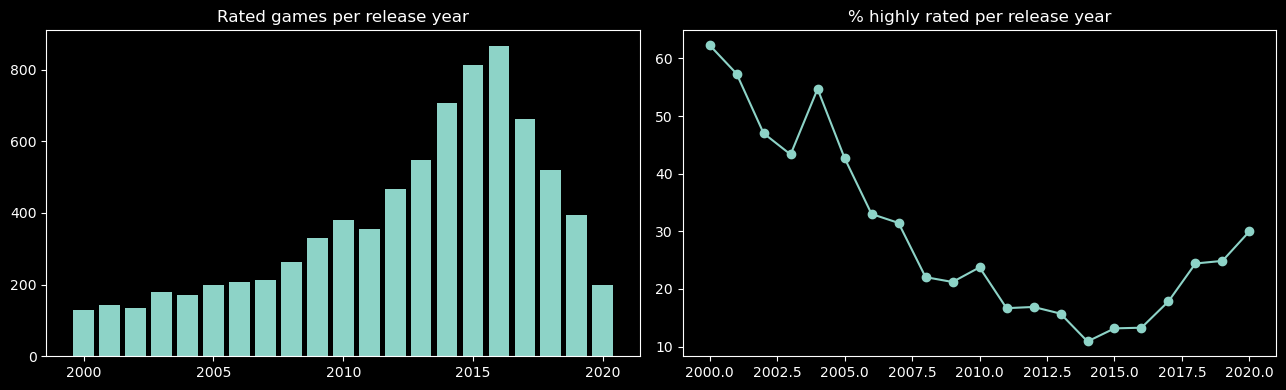

              n_games  mean_rating  pct_high
release_year                                
2000.0            130         3.97      0.62
2001.0            143         3.95      0.57
2002.0            134         3.88      0.47
2003.0            180         3.78      0.43
2004.0            170         3.90      0.55
2005.0            199         3.78      0.43
2006.0            206         3.69      0.33
2007.0            213         3.66      0.31
2008.0            263         3.48      0.22
2009.0            330         3.48      0.21
2010.0            379         3.47      0.24
2011.0            354         3.33      0.17
2012.0            468         3.32      0.17
2013.0            547         3.27      0.16
2014.0            707         3.10      0.11
2015.0            813         3.07      0.13
2016.0            866         3.07      0.13
2017.0            661         3.34      0.18
2018.0            520         3.49      0.24
2019.0            394         3.55      0.25
2020.0    

In [121]:
#does the game year matter?
yr = rated[(rated['release_year'] >= 2000) & (rated['release_year'] <= 2020)]
by_year = yr.groupby('release_year').agg(n_games=('rating', 'size'),
                                         mean_rating=('rating', 'mean'),
                                         pct_high=('high_rated', 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(by_year.index, by_year['n_games'])
axes[0].set_title('Rated games per release year')
axes[1].plot(by_year.index, by_year['pct_high']*100, marker='o')
axes[1].set_title('% highly rated per release year')
plt.tight_layout()
plt.show()
print(by_year.round(2).to_string())

# 62% of high from 2000, then 13% in 2016 then 30% in 2020
# old games people rate, 2014 to 2016 flood of mobile & indie games

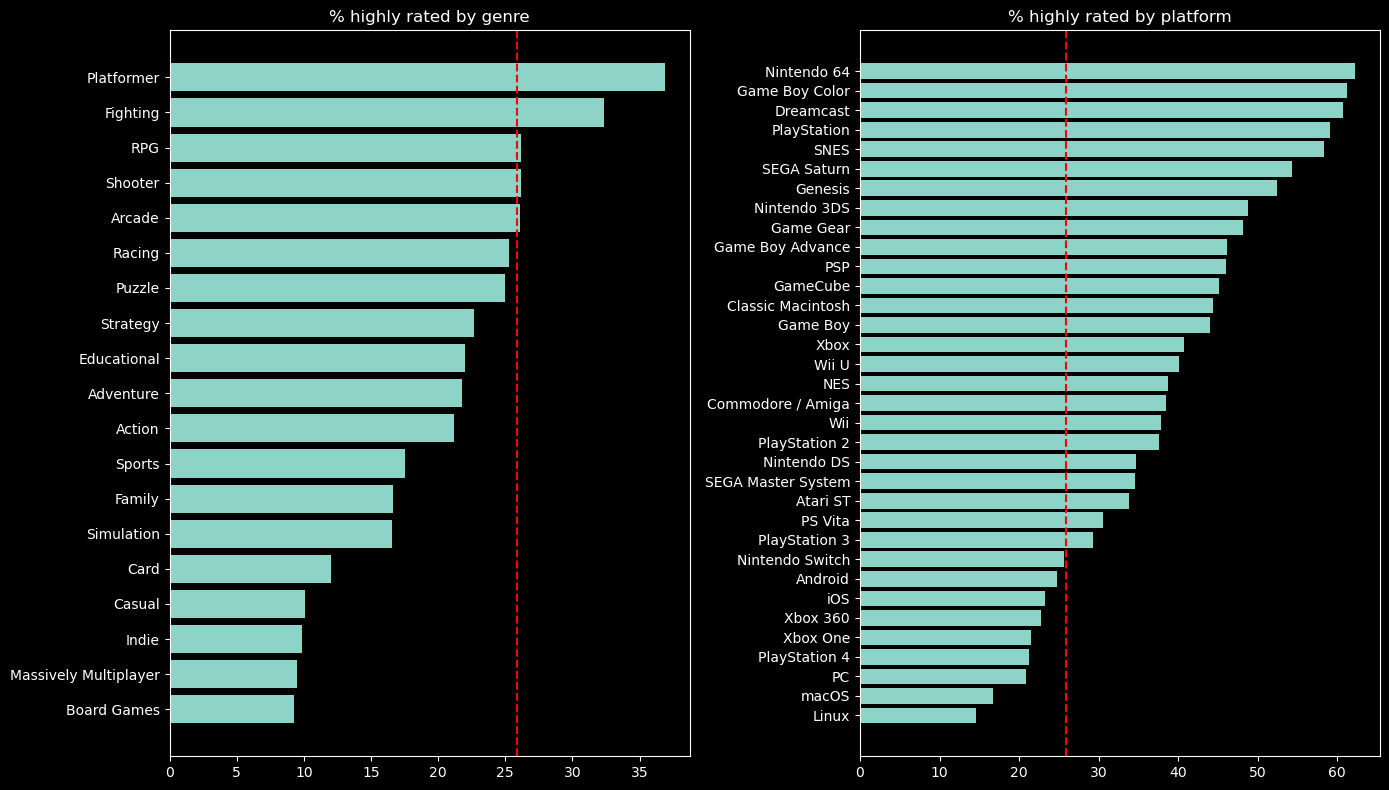

          size   mean
n_genres             
1.0       2258  0.376
2.0       2987  0.277
3.0       1974  0.173
4.0        926  0.118
5.0        328  0.082
6.0         76  0.039
7.0         19  0.105


In [122]:
# genres, platforms and number of genres
def explode_stats(col, min_games=50):
    e = rated.assign(**{col: rated[col].str.split(r'\|\|')}).explode(col).dropna(subset=[col])
    s = e.groupby(col).agg(n_games=('rating', 'size'),
                           mean_rating=('rating', 'mean'),
                           pct_high=('high_rated', 'mean'))
    return s[s['n_games'] >= min_games].sort_values('pct_high', ascending=False)

genre_stats = explode_stats('genres')
platform_stats = explode_stats('platforms')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].barh(genre_stats.index[::-1], genre_stats['pct_high'][::-1]*100)
axes[0].set_title('% highly rated by genre')
axes[1].barh(platform_stats.index[::-1], platform_stats['pct_high'][::-1]*100)
axes[1].set_title('% highly rated by platform')
for ax in axes:
    ax.axvline(rated['high_rated'].mean()*100, color='red', linestyle='--')   # overall average
plt.tight_layout()
plt.show()

rated['n_genres'] = rated['genres'].str.split(r'\|\|').str.len()
print(rated.groupby('n_genres')['high_rated'].agg(['size', 'mean']).round(3).head(7))

# Genres: Platformer (37%) and Fighting (32%) are best. Indie (10%), Casual (10%) and Massively Multiplayer (9.5%) are worst.
# Platforms: retro consoles (N64, PlayStation, SNES) are around 55–62%, while PC is 21% and Linux 15%. That's the survivorship effect from Cell 5 showing up again.
# Number of genres: games tagged with 1 genre are 38% high, and at 5 genres it's 8%. It's an odd but strong pattern, and it's an easy feature to build.

In [123]:
#ESRB and missing values
rated['esrb_filled'] = rated['esrb_rating'].fillna('Missing')
print(rated.groupby('esrb_filled')['high_rated'].agg(['size', 'mean']).round(3))

cols = ['genres', 'platforms', 'developers', 'publishers', 'esrb_rating', 'released', 'website', 'metacritic']
miss = pd.DataFrame({'pct_missing': rated[cols].isnull().mean()*100})
for c in cols:
    m = rated[c].isnull()
    miss.loc[c, 'pct_high_if_missing'] = rated.loc[m, 'high_rated'].mean()*100
    miss.loc[c, 'pct_high_if_present'] = rated.loc[~m, 'high_rated'].mean()*100
print(miss.round(1))

# ESRB is missing for 58% of rated games, but "missing" itself isn't informative (24.6% high vs 27.7% when present). Among known ratings, Mature (37%) beats Everyone 10+ (18%).
# Missing genres, developers and platforms look informative (45–50% high if missing), but that's only about 4%, 2% and 0.03% of games, so it's small-sample noise. We shouldn't build features around it.

                size   mean
esrb_filled                
Adults Only      134  0.179
Everyone         475  0.299
Everyone 10+     868  0.183
Mature           958  0.367
Missing         5208  0.246
Rating Pending    12  0.500
Teen            1314  0.273
             pct_missing  pct_high_if_missing  pct_high_if_present
genres               3.9                 45.2                 25.1
platforms            0.0                 50.0                 25.9
developers           2.0                 48.0                 25.4
publishers           3.4                 23.0                 26.0
esrb_rating         58.1                 24.6                 27.7
released             1.0                 15.7                 26.0
website             32.9                 36.7                 20.6
metacritic          61.3                 24.7                 27.8


In [124]:
# how many diff developers and publishers are there?
for col in ['developers', 'publishers']:
    s = rated[col].dropna().str.split(r'\|\|').explode()
    vc = s.value_counts()
    print(f"--- {col}: {len(vc)} unique values")
    print(f"   appear >=10 times: {(vc >= 10).sum()}   |  top 50 cover {s.isin(vc.head(50).index).mean()*100:.0f}% of entries")
    print(vc.head(5).to_string())

--- developers: 5201 unique values
   appear >=10 times: 207   |  top 50 cover 21% of entries
developers
Sony Interactive Entertainment    228
Nintendo                          178
Capcom                            160
Electronic Arts                   145
SEGA                              138
--- publishers: 3214 unique values
   appear >=10 times: 176   |  top 50 cover 42% of entries
publishers
Electronic Arts          474
Nintendo                 429
SEGA                     297
Ubisoft Entertainment    282
Microsoft Studios        255


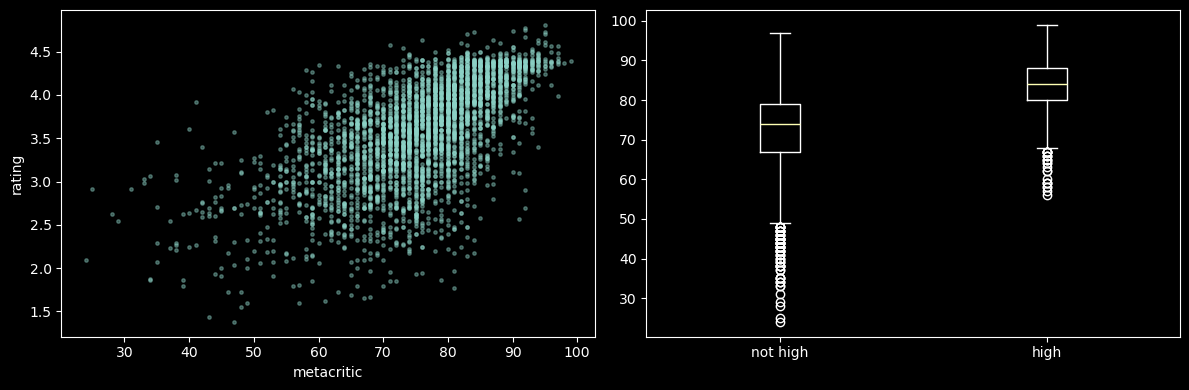

3470 rated games have a metacritic score; correlation = 0.62
has_website {False: 0.367, True: 0.206}
has_playtime {False: 0.43, True: 0.197}
has_achievements {False: 0.408, True: 0.152}
in_series {False: 0.21, True: 0.44}


In [125]:
# metacritic and a few yes/no features
m = rated.dropna(subset=['metacritic'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(m['metacritic'], m['rating'], s=6, alpha=0.4)
axes[0].set_xlabel('metacritic')
axes[0].set_ylabel('rating')
axes[1].boxplot([m.loc[m['high_rated'] == 0, 'metacritic'],
                 m.loc[m['high_rated'] == 1, 'metacritic']],
                tick_labels=['not high', 'high'])
plt.tight_layout()
plt.show()
print(f"{len(m)} rated games have a metacritic score; correlation = {m[['metacritic','rating']].corr().iloc[0,1]:.2f}")

rated['has_website'] = rated['website'].notna()
rated['has_playtime'] = rated['playtime'] > 0
rated['has_achievements'] = rated['achievements_count'] > 0
rated['in_series'] = rated['game_series_count'] > 0
for c in ['has_website', 'has_playtime', 'has_achievements', 'in_series']:
    print(c, rated.groupby(c)['high_rated'].mean().round(3).to_dict())
    
# Metacritic: 3,470 rated games (39%) have a score, with correlation 0.62. Highly rated games have a median metacritic of 84, against 74 for the rest.
# Yes/no features:
#in_series is a strong one: 44% high inside a series vs 21% outside.
#has_website is reversed: games with a website are less often high (21% vs 37%). That is again old classics vs modern indie.
#has_playtime and has_achievements are also lower, probably for the same reason.

## Clean and Build Dataset

In [126]:
#define leakage, select columns and drop bad rows
# Decision: columns the model must NOT see, these columns include data taken after game release
LEAKAGE_COLS = ['rating_top', 'ratings_count', 'reviews_count', 'suggestions_count', 'playtime',
                'added_status_yet', 'added_status_owned', 'added_status_beaten',
                'added_status_toplay', 'added_status_dropped', 'added_status_playing']

# columns we carry forward from rated (id/name/rating/metacritic are NOT features, just for reference)
KEEP_RAW = ['id', 'name', 'rating', 'high_rated', 'release_year', 'genres', 'platforms', 'developers',
            'publishers', 'esrb_rating', 'website', 'achievements_count', 'game_series_count', 'metacritic']
work = rated[KEEP_RAW].copy()

# Decision: drop rows with missing or impossible release year
before = len(work)
work = work[work['release_year'].notna() & (work['release_year'] <= 2020)].copy()
work['release_year'] = work['release_year'].astype(int)
work = work.reset_index(drop=True)
print(f"Rows before: {before} | after: {len(work)} | dropped: {before - len(work)}")

Rows before: 8969 | after: 8878 | dropped: 91


In [127]:
# simple numeric and yes/no features
feat = pd.DataFrame(index=work.index)

feat['release_year'] = work['release_year']
feat['n_genres'] = work['genres'].fillna('').apply(lambda s: len([x for x in s.split('||') if x]))
feat['n_platforms'] = work['platforms'].fillna('').apply(lambda s: len([x for x in s.split('||') if x]))
feat['has_website'] = work['website'].notna().astype(int)
feat['has_achievements'] = (work['achievements_count'] > 0).astype(int)
feat['in_series'] = (work['game_series_count'] > 0).astype(int)

# ESRB: 58% missing, so "Missing" becomes its own category
esrb = work['esrb_rating'].fillna('Missing').replace({'Rating Pending': 'Missing'})
feat = pd.concat([feat, pd.get_dummies(esrb, prefix='esrb').astype(int)], axis=1)

# Decision: developer / publisher "experience" = log(number of games they made in the FULL dataset)
# those with at least 10 rated games are kept
def build_experience(col_name):
    counts = df[col_name].dropna().str.split(r'\|\|').explode().str.strip().value_counts()
    return work[col_name].fillna('').apply(
        lambda s: np.log1p(max([counts.get(x.strip(), 0) for x in s.split('||') if x.strip()], default=0)))

feat['dev_experience'] = build_experience('developers')
feat['pub_experience'] = build_experience('publishers')
print(feat.shape)

(8878, 14)


In [128]:
# multi-hot columns for genres, platforms, developers and publishers
def multi_hot(series, prefix, min_count):
    """One 0/1 column per value that appears in >= min_count games.
       A game can have several 1s (e.g. genre_Action AND genre_Indie).
       'all_rare' = 1 when none of the game's values made the cut."""
    lists = series.fillna('').apply(lambda s: {x.strip() for x in s.split('||') if x.strip()})
    counts = pd.Series([x for l in lists for x in l]).value_counts()
    keep = list(counts[counts >= min_count].index)
    out = pd.DataFrame({f'{prefix}_{k}': lists.apply(lambda l, k=k: int(k in l)) for k in keep},
                       index=series.index)
    out[f'{prefix}_all_rare'] = lists.apply(lambda l: int(len(l & set(keep)) == 0))
    return out

# Decision: minimum games for a value to get its own column
MIN_GENRE, MIN_PLATFORM, MIN_DEV, MIN_PUB = 30, 30, 10, 10

genre_feats    = multi_hot(work['genres'],     'genre', MIN_GENRE)
platform_feats = multi_hot(work['platforms'],  'plat',  MIN_PLATFORM)
dev_feats      = multi_hot(work['developers'], 'dev',   MIN_DEV)
pub_feats      = multi_hot(work['publishers'], 'pub',   MIN_PUB)

for name, f in [('genres', genre_feats), ('platforms', platform_feats),
                ('developers', dev_feats), ('publishers', pub_feats)]:
    print(f"{name}: {f.shape[1]} columns")
print('games with only rare developers:', dev_feats['dev_all_rare'].mean().round(3))
print('games with only rare publishers:', pub_feats['pub_all_rare'].mean().round(3))

genres: 20 columns
platforms: 37 columns
developers: 207 columns
publishers: 176 columns
games with only rare developers: 0.534
games with only rare publishers: 0.359


In [129]:
# assemble, safety checks, save
import re, os

X = pd.concat([feat, genre_feats, platform_feats, dev_feats, pub_feats], axis=1)

# clean column names (some ML libraries choke on spaces/symbols)
X.columns = [re.sub(r'[^0-9a-zA-Z_]+', '_', c).strip('_') for c in X.columns]

# safety checks: this crashes loudly if something is wrong
assert X.columns.is_unique, "column names collided after cleaning"
assert not X.isnull().any().any(), "there are NaNs in the features"
assert not set(LEAKAGE_COLS) & set(X.columns), "leakage column slipped in!"

final = pd.concat([work[['id', 'name', 'rating', 'high_rated', 'metacritic']], X], axis=1)
print("Final shape:", final.shape)
print("Number of features:", X.shape[1])
print(final['high_rated'].value_counts(normalize=True).round(3))

os.makedirs('../data/processed', exist_ok=True)
final.to_csv('../data/processed/model_data.csv', index=False)
print("Saved to ../data/processed/model_data.csv")

Final shape: (8878, 459)
Number of features: 454
high_rated
0    0.74
1    0.26
Name: proportion, dtype: float64
Saved to ../data/processed/model_data.csv
